<a href="https://colab.research.google.com/github/thvsbg/PyTorch/blob/main/01_Pytorch_workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import torch
from torch import nn
import matplotlib.pyplot as plt

In [3]:
weight=0.7
bias=0.3

start=0
end=1
step=0.02
X=torch.arange(start,end,step).unsqueeze(1)
y=weight*X+bias
print(y[:10])
# print(X)

tensor([[0.3000],
        [0.3140],
        [0.3280],
        [0.3420],
        [0.3560],
        [0.3700],
        [0.3840],
        [0.3980],
        [0.4120],
        [0.4260]])


In [4]:
split=int(0.8*len(X))
X_train,X_test=X[:split],X[split:]
y_train,y_test=y[:split],y[split:]

In [5]:
def plot_predictions(train_data=X_train,train_labels=y_train,test_data=X_test,test_labels=y_test,predictions=None):
  plt.figure(figsize=(4,4))
  plt.scatter(train_data,train_labels,c="b")
  plt.scatter(test_data,test_labels,c="g")
  if predictions is not None:
    plt.scatter(test_data,predictions,c="r")
  plt.xticks(torch.arange(0,1,0.1))
  plt.yticks(torch.arange(0,1,0.1))
  plt.show()

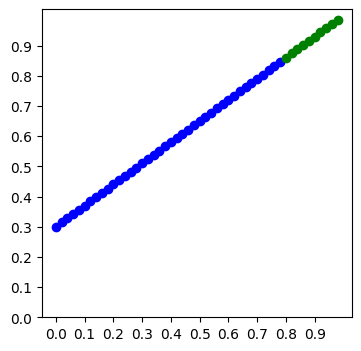

In [6]:
plot_predictions()

In [7]:
##create linear regression model
class LinearRegression(nn.Module):
  def __init__(self):
    super().__init__()

    self.weights=nn.Parameter(torch.rand(1,requires_grad=True,dtype=torch.float))
    self.bias=nn.Parameter(torch.rand(1,requires_grad=True,dtype=torch.float))

  def forward(self,x:torch.Tensor):
    return self.weights*x+self.bias


In [8]:
torch.manual_seed(42)
torch.randn(1)


tensor([0.3367])

In [9]:
torch.manual_seed(42)
model_0=LinearRegression()
list(model_0.parameters())


[Parameter containing:
 tensor([0.8823], requires_grad=True),
 Parameter containing:
 tensor([0.9150], requires_grad=True)]

In [10]:
##to get named paramters
model_0.state_dict()

OrderedDict([('weights', tensor([0.8823])), ('bias', tensor([0.9150]))])

In [11]:
y_pred=model_0(X_test)
y_pred

tensor([[1.6208],
        [1.6385],
        [1.6561],
        [1.6738],
        [1.6914],
        [1.7090],
        [1.7267],
        [1.7443],
        [1.7620],
        [1.7796]], grad_fn=<AddBackward0>)

Making predictions using torch.inference_mode()

In [12]:
with torch.inference_mode():
  y_preds=model_0(X_test)
y_preds


tensor([[1.6208],
        [1.6385],
        [1.6561],
        [1.6738],
        [1.6914],
        [1.7090],
        [1.7267],
        [1.7443],
        [1.7620],
        [1.7796]])

In [13]:
loss_fn=nn.L1Loss()
opt=torch.optim.SGD(params=model_0.parameters(),lr=0.01)

Training loop

In [14]:
epoch_count=[]
loss_values=[]
test_loss_values=[]

epochs= 200

# 0 Loop through the data
for epoch in range(epochs):
  #set the model to training mode
  model_0.train() # train mode sets all the paramters with "require grad=True" to require gradient

  #1. Forward pass
  y_pred=model_0(X_train)

  #2. calculate loss
  loss=loss_fn(y_pred,y_train)
  if epoch==1:
    print(loss.dtype)
  print(f'loss is : {loss}')

  #3. Optimizer zero grad
  opt.zero_grad()

  #4. perform backpropagation on the loss wrt to paramters of the model
  loss.backward()

  #5. step the optimizer
  opt.step()

  ## testing
  model_0.eval() ##turns off settings tha are not needed for testing like dropout/batchnorm etc
  with torch.inference_mode():
    test_pred=model_0(X_test)
    test_loss=loss_fn(test_pred,y_test)

  if epoch%10==0:
    epoch_count.append(epoch)
    loss_values.append(loss)
    test_loss_values.append(test_loss)
    print(f'Epcoh:{epoch} |Loss"{loss}| test loss: {test_loss}')
    print(model_0.state_dict())



  print(model_0.state_dict())






loss is : 0.6860889196395874
Epcoh:0 |Loss"0.6860889196395874| test loss: 0.7637526988983154
OrderedDict({'weights': tensor([0.8784]), 'bias': tensor([0.9050])})
OrderedDict({'weights': tensor([0.8784]), 'bias': tensor([0.9050])})
torch.float32
loss is : 0.6745679974555969
OrderedDict({'weights': tensor([0.8745]), 'bias': tensor([0.8950])})
loss is : 0.6630470156669617
OrderedDict({'weights': tensor([0.8706]), 'bias': tensor([0.8850])})
loss is : 0.6515260338783264
OrderedDict({'weights': tensor([0.8667]), 'bias': tensor([0.8750])})
loss is : 0.6400049924850464
OrderedDict({'weights': tensor([0.8628]), 'bias': tensor([0.8650])})
loss is : 0.6284840703010559
OrderedDict({'weights': tensor([0.8589]), 'bias': tensor([0.8550])})
loss is : 0.6169630289077759
OrderedDict({'weights': tensor([0.8550]), 'bias': tensor([0.8450])})
loss is : 0.6054420471191406
OrderedDict({'weights': tensor([0.8511]), 'bias': tensor([0.8350])})
loss is : 0.5939210653305054
OrderedDict({'weights': tensor([0.8472])

In [15]:
print(loss_values[:10])
##each value inside the loss arrays is a tensor attached to the graphing curve and they need to be detached and converted to numpy to plot the values in loss curves.

[tensor(0.6861, grad_fn=<MeanBackward0>), tensor(0.5709, grad_fn=<MeanBackward0>), tensor(0.4557, grad_fn=<MeanBackward0>), tensor(0.3405, grad_fn=<MeanBackward0>), tensor(0.2252, grad_fn=<MeanBackward0>), tensor(0.1100, grad_fn=<MeanBackward0>), tensor(0.0097, grad_fn=<MeanBackward0>), tensor(0.0062, grad_fn=<MeanBackward0>), tensor(0.0028, grad_fn=<MeanBackward0>), tensor(0.0071, grad_fn=<MeanBackward0>)]


Text(0.5, 0, 'Epcoh')

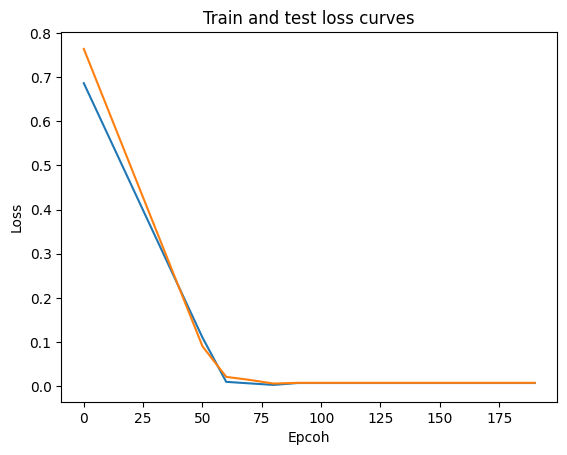

In [16]:
##plot loss curves

import numpy as np
plt.plot(epoch_count,[loss.detach().numpy() for loss in loss_values],label="Train loss")
plt.plot(epoch_count, [test_loss.detach().numpy() for test_loss in test_loss_values],label="Test loss")
plt.title("Train and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epcoh")

In [17]:
with torch.inference_mode():
  y_preds=model_0(X_test)
y_preds

tensor([[0.8661],
        [0.8801],
        [0.8940],
        [0.9080],
        [0.9220],
        [0.9359],
        [0.9499],
        [0.9638],
        [0.9778],
        [0.9917]])

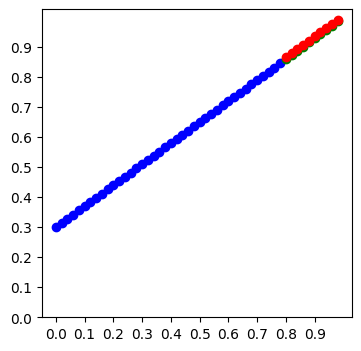

In [18]:
plot_predictions(predictions=y_preds)

In [20]:
#saving model
from pathlib import Path

#1. Create models directory
MODEL_PATH=Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

#2. Model save path
MODEL_NAME="01_pytorch_workflow_model_0.pth"
MODEL_SAVE_PATH=MODEL_PATH/MODEL_NAME

#3.save the model state dict
torch.save(obj=model_0.state_dict(),f=MODEL_SAVE_PATH)


In [21]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.6977])), ('bias', tensor([0.3080]))])

In [22]:
##Loading a pytorch model
loaded_model_0=LinearRegression()

##load the saved state_dict of model_0 to the new instance
loaded_model_0.load_state_dict(torch.load(f=MODEL_SAVE_PATH))


<All keys matched successfully>

In [23]:
loaded_model_0.state_dict()

OrderedDict([('weights', tensor([0.6977])), ('bias', tensor([0.3080]))])